In [1]:
!pip install optuna catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.6 MB/s eta 0:00:00


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

In [3]:
import optuna
import catboost
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)
from catboost import CatBoostClassifier, Pool

import warnings
warnings.filterwarnings('ignore')

In [4]:
from google.colab import drive
drive.mount("/content/gdrive", force_remount=True)

Mounted at /content/gdrive


In [5]:
df=pd.read_csv('/content/gdrive/My Drive/studentdepression.csv')
df.head()

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [6]:
print("-")
print(df.info())
print("-")
print(df.isnull().sum())
print("-")
print(df.describe())

-
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  object 
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  object 
 4   Profession                             27901 non-null  object 
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  object 
 11  

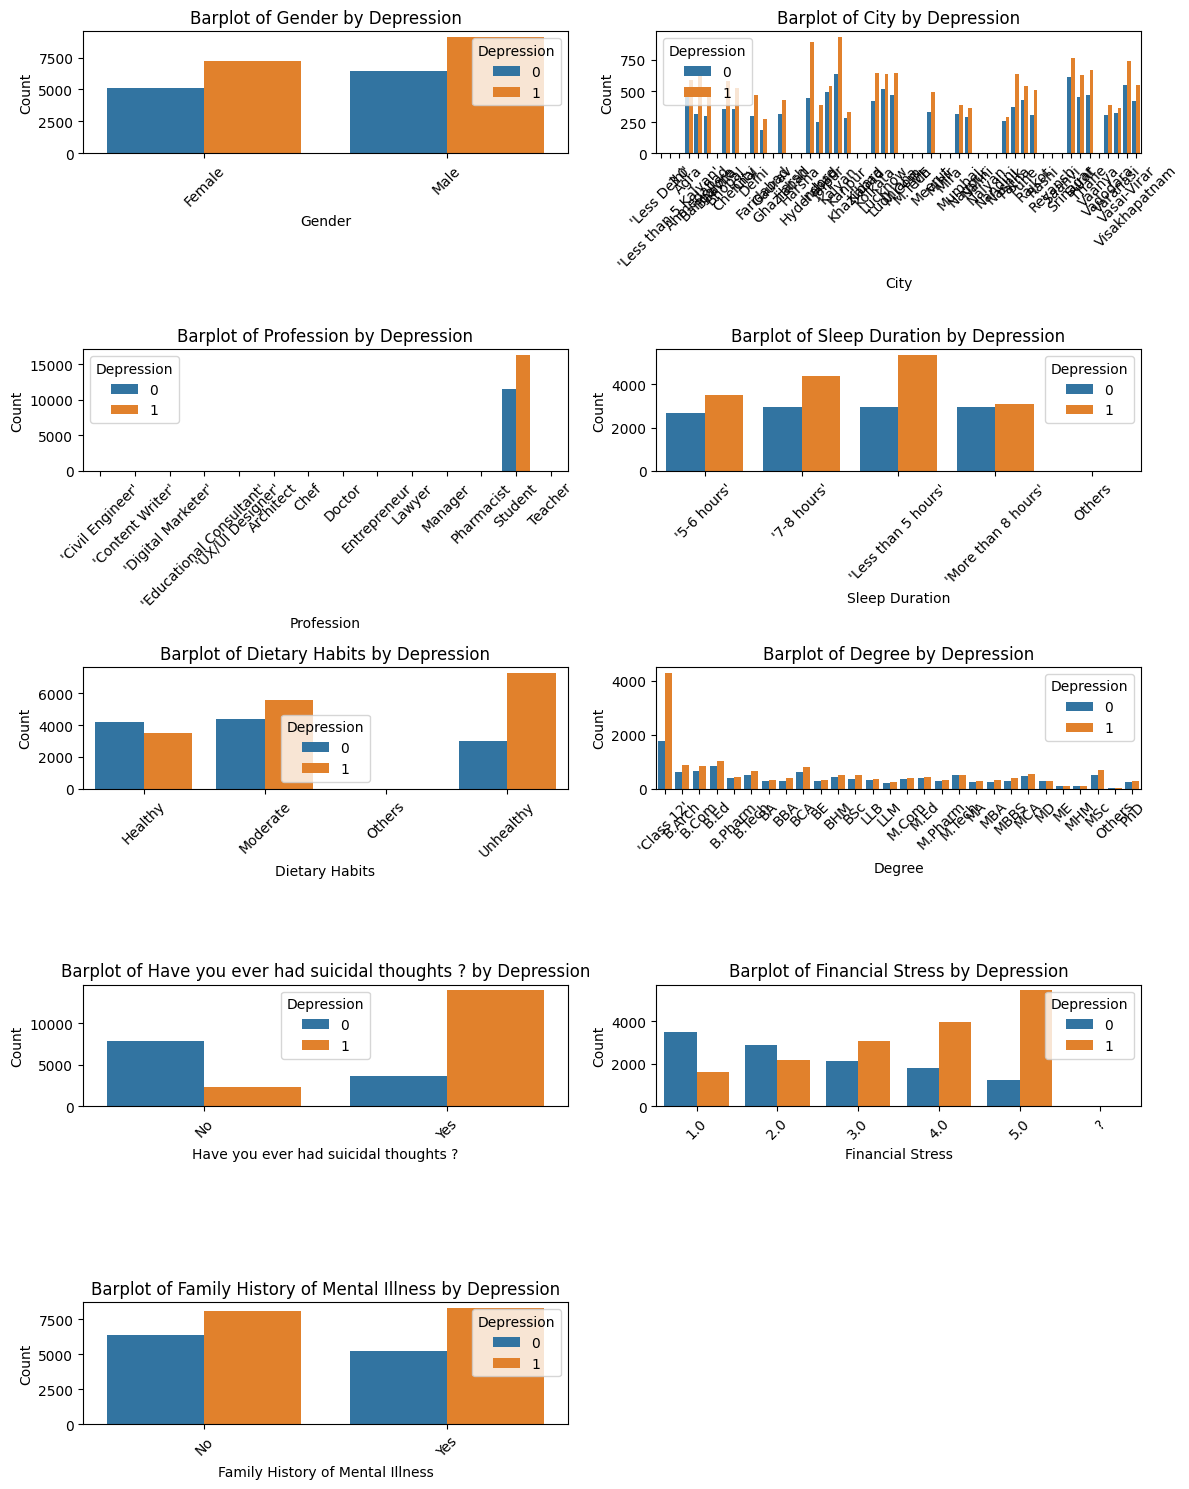

In [7]:
target = 'Depression'

bar_cols = df.select_dtypes(include = ['object', 'category']).columns.drop(target, errors = 'ignore')

b_features = len(bar_cols)
b_cols = 2
b_rows = (b_features + b_cols - 1) // b_cols

fig, axes = plt.subplots(b_rows, b_cols, figsize = (12, b_rows*3))
axes = axes.flatten()

for i, col in enumerate(bar_cols):
    counts = (
        df.groupby([col, target]).size().reset_index(name = 'count')
    )

    sns.barplot(
        x=col,
        y = 'count',
        hue = target,
        data = counts,
        ax = axes[i]
    )
    axes[i].set_title(f"Barplot of {col} by {target}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(title=target)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

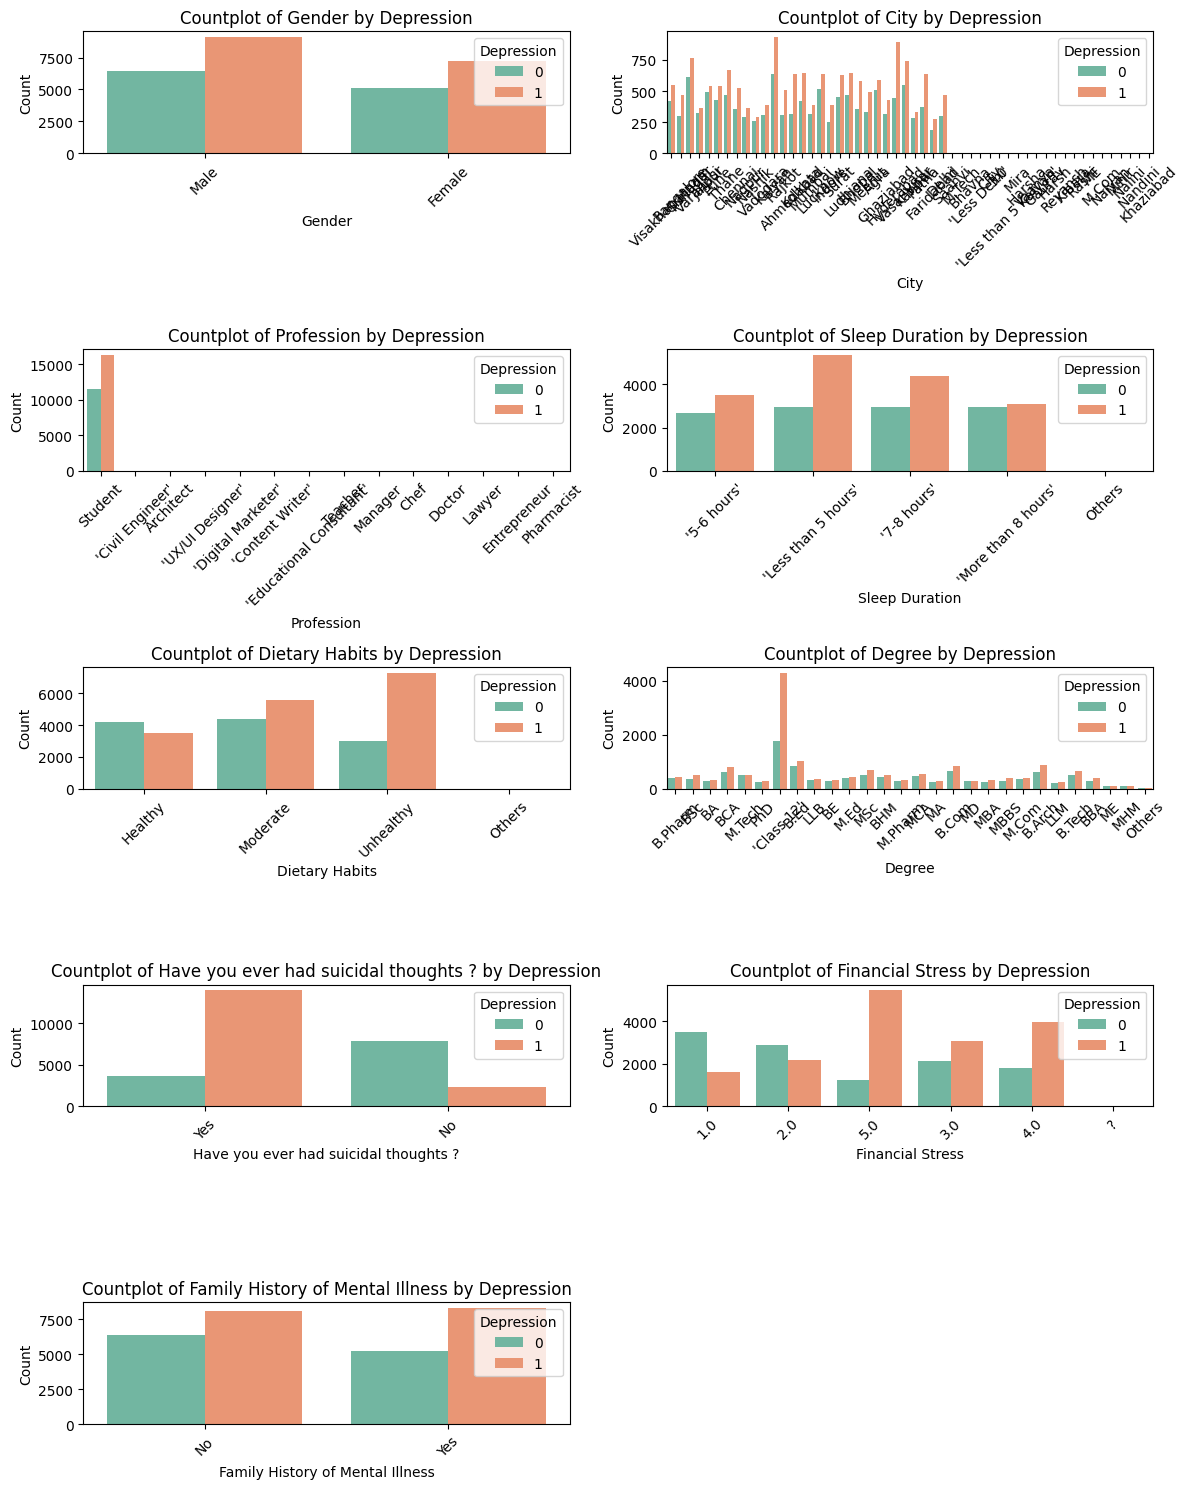

In [8]:
cat_cols = df.select_dtypes(include = ['object', 'category']).columns.drop(target, errors = 'ignore')

c_features = len(cat_cols)
c_cols = 2
c_rows = (c_features + c_cols - 1) // c_cols

figc, axesc = plt.subplots(c_rows, c_cols, figsize = (12, c_rows*3))
axesc = axesc.flatten()

for i, col in enumerate(bar_cols):
    sns.countplot(
        x=col,
        hue = target,
        data = df,
        ax = axesc[i],
        palette='Set2'
    )
    axesc[i].set_title(f"Countplot of {col} by {target}")
    axesc[i].set_xlabel(col)
    axesc[i].set_ylabel("Count")
    axesc[i].tick_params(axis='x', rotation=45)
    axesc[i].legend(title=target)

for j in range(i + 1, len(axesc)):
    axesc[j].axis('off')

plt.tight_layout()
plt.show()

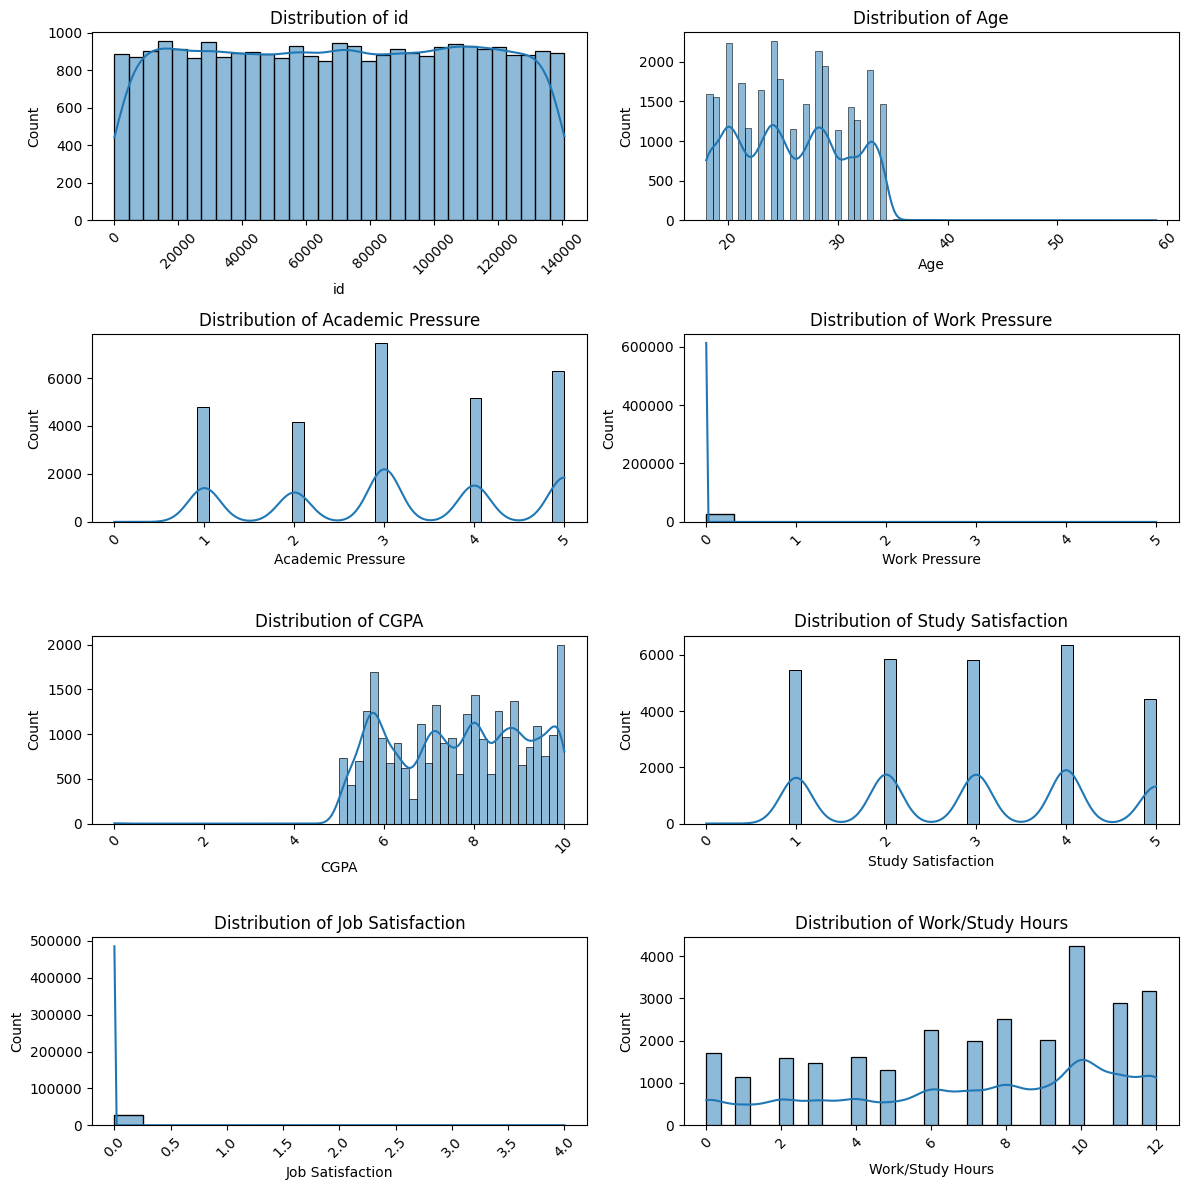

In [9]:
num_cols = df.select_dtypes(include = np.number).columns.drop(target, errors = 'ignore')

n_features = len(num_cols)
n_cols = 2
n_rows = (n_features + n_cols - 1) // n_cols

fign, axesn = plt.subplots(n_rows, n_cols, figsize = (12, n_rows*3))
axesn = axesn.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        x = col,
        kde = True,
        data = df,
        ax = axesn[i]
    )
    axesn[i].set_title(f"Distribution of {col}")
    axesn[i].set_xlabel(col)
    axesn[i].set_ylabel("Count")
    axesn[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axesn)):
    axesn[j].axis('off')

plt.tight_layout()
plt.show()

In [10]:
#droping cols which have no contribution
#Here everyone is student so profession doesnt make sense
#work pressure and job statisfication are 99% imbalanced
cols_to_drop = ['id', 'Profession', 'Work Pressure', 'Job Satisfaction']

df.drop(cols_to_drop, axis = 1, inplace = True)
df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,'5-6 hours',Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,2.0,5.90,5.0,'5-6 hours',Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,3.0,7.03,5.0,'Less than 5 hours',Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,3.0,5.59,2.0,'7-8 hours',Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,4.0,8.13,3.0,'5-6 hours',Moderate,M.Tech,Yes,1.0,1.0,No,0


In [11]:
# converting sleep duration to int
temp = df['Sleep Duration'].str.extract(r'(\d+)-(\d+)')

temp = temp.apply(pd.to_numeric, errors = 'coerce')

df['Sleep Duration int'] = (
    temp.mean(axis = 1)
        .round()
        .fillna(0)
        .astype(int)

)

medain_val = df.loc[df['Sleep Duration int'] != 0, 'Sleep Duration int'].median()
df['Sleep Duration int'] = df['Sleep Duration int'].replace(0, medain_val)
df.drop(['Sleep Duration'], axis = 1, inplace = True)

df.head()

,Gender,Age,City,Academic Pressure,CGPA,Study Satisfaction,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,Sleep Duration int
0,Male,33.0,Visakhapatnam,5.0,8.97,2.0,Healthy,B.Pharm,Yes,3.0,1.0,No,1,6
1,Female,24.0,Bangalore,2.0,5.90,5.0,Moderate,BSc,No,3.0,2.0,Yes,0,6
2,Male,31.0,Srinagar,3.0,7.03,5.0,Healthy,BA,No,9.0,1.0,Yes,0,8
3,Female,28.0,Varanasi,3.0,5.59,2.0,Moderate,BCA,Yes,4.0,5.0,Yes,1,8
4,Female,25.0,Jaipur,4.0,8.13,3.0,Moderate,M.Tech,Yes,1.0,1.0,No,0,6


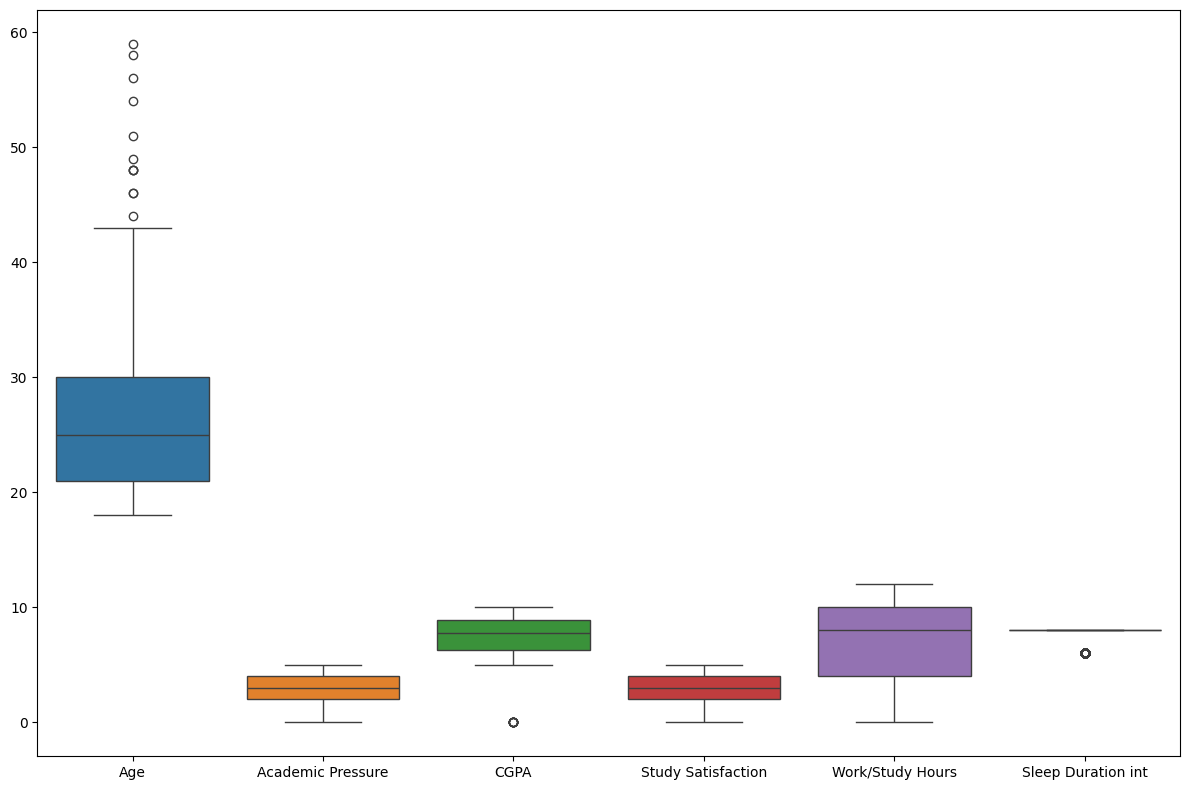

In [12]:
box_cols = df.select_dtypes(include = np.number).columns.drop(target, errors = 'ignore')

plt.figure(figsize=(12, 8))
sns.boxplot(data = df[box_cols])
plt.tight_layout()
plt.show()


In [14]:
X = df.drop(['Depression'], axis = 1)
y = df['Depression']

cate_cols = X.select_dtypes(include = ['object', 'category']).columns.tolist()
cat_cols = list(cat_cols)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify=y)

#CatBoostClassifier

In [15]:
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix

# Detect categorical columns
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
print("Categorical cols used:", cat_cols)

# Get column indices (CatBoost needs index, not names)
cat_features_idx = [X_train.columns.get_loc(col) for col in cat_cols]

# Initialize CatBoost model
cat_model = CatBoostClassifier(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=42,
    verbose=200
)

# Train model
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features_idx,
    eval_set=(X_test, y_test),
    use_best_model=True
)

# Predictions
y_proba = cat_model.predict_proba(X_test)[:, 1]
y_pred = (y_proba >= 0.5).astype(int)

# Metrics
print("Validation metrics:")
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
0:	test: 0.8957463	best: 0.8957463 (0)	total: 161ms	remaining: 5m 22s
200:	test: 0.9182637	best: 0.9182738 (198)	total: 27s	remaining: 4m 1s
400:	test: 0.9184757	best: 0.9184757 (400)	total: 47.9s	remaining: 3m 10s
600:	test: 0.9183835	best: 0.9185105 (452)	total: 1m 4s	remaining: 2m 30s
800:	test: 0.9183774	best: 0.9185105 (452)	total: 1m 24s	remaining: 2m 6s
1000:	test: 0.9181500	best: 0.9185105 (452)	total: 1m 37s	remaining: 1m 37s
1200:	test: 0.9180261	best: 0.9185105 (452)	total: 1m 46s	remaining: 1m 10s
1400:	test: 0.9179204	best: 0.9185105 (452)	total: 1m 56s	remaining: 49.8s
1600:	test: 0.9177811	best: 0.9185105 (452)	total: 2m 7s	remaining: 31.9s
1800:	test: 0.9175327	best: 0.9185105 (452)	total: 2m 16s	remaining: 15s
1999:	test: 0.9174103	best: 0.9185105 (452)	total: 2m 27s	remaining: 0us

bestTest = 0.918510457

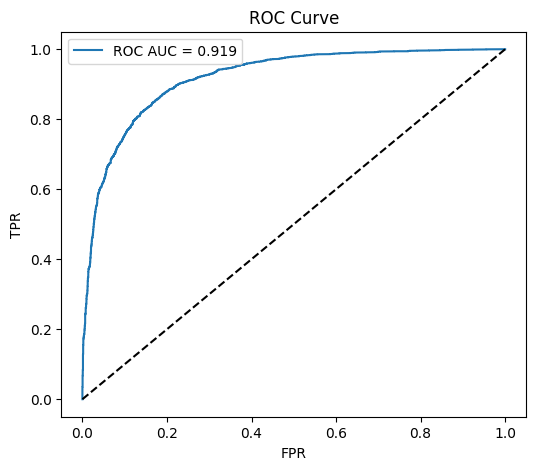

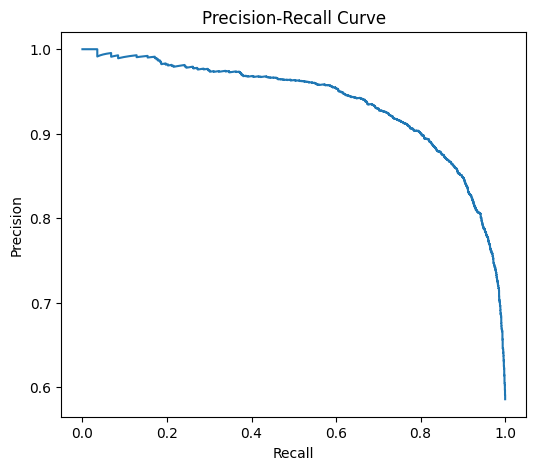

In [16]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.show()

# PR-curve
p, r, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6,5))
plt.plot(r, p)
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Precision-Recall Curve'); plt.show()

In [17]:
import tqdm

target = 'Depression'
N_SPLITS = 5
RANDOM_STATE = 42
SAVE_BEST_MODEL = True
MODEL_SAVE_PREFIX = "catboost_fold"

CB_PARAMS = dict(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    eval_metric='AUC',
    random_seed=RANDOM_STATE,
    early_stopping_rounds=50,
    verbose=100,
    task_type='CPU'
)

X = df.drop(columns=[target]).copy()
y = df[target].copy()

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof_preds = np.zeros(len(X))
oof_labels = y.values
fold_metrics = []
feature_importances = []
models = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), 1):
    print(f"\n=== Fold {fold} ===")
    X_tr, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

    cat_cols = list(X_tr.select_dtypes(include=['object', 'category']).columns)
    print("Categorical cols used:", cat_cols)

    num_cols = X_tr.select_dtypes(include=['number']).columns.tolist()
    if len(num_cols) > 0:
        X_tr[num_cols] = X_tr[num_cols].fillna(X_tr[num_cols].median())
        X_val[num_cols] = X_val[num_cols].fillna(X_tr[num_cols].median())

    if len(cat_cols) > 0:
        X_tr[cat_cols] = X_tr[cat_cols].fillna('missing').astype(str)
        X_val[cat_cols] = X_val[cat_cols].fillna('missing').astype(str)

    train_pool = Pool(X_tr, y_tr, cat_features=cat_cols)
    val_pool   = Pool(X_val, y_val, cat_features=cat_cols)

    final_model = CatBoostClassifier(**CB_PARAMS)
    final_model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    val_preds = final_model.predict_proba(X_val)[:, 1]
    oof_preds[val_idx] = val_preds

    y_pred_label = (val_preds >= 0.5).astype(int)
    auc = roc_auc_score(y_val, val_preds)
    acc = accuracy_score(y_val, y_pred_label)
    f1 = f1_score(y_val, y_pred_label)
    print(f"Fold {fold} AUC: {auc:.6f}  Acc: {acc:.4f}  F1: {f1:.4f}")
    print("Confusion matrix:\n", confusion_matrix(y_val, y_pred_label))
    fold_metrics.append({'fold': fold, 'auc': auc, 'acc': acc, 'f1': f1})

    try:
        fi = pd.Series(final_model.get_feature_importance(), index=X_tr.columns).sort_values(ascending=False)
    except Exception:
        fi = pd.Series(final_model.get_feature_importance(type='PredictionValuesChange'), index=X_tr.columns).sort_values(ascending=False)
    feature_importances.append(fi)

    models.append(final_model)


oof_auc = roc_auc_score(oof_labels, oof_preds)
print("\n=== CV Summary ===")
print("OOF ROC AUC:", oof_auc)

metrics_df = pd.DataFrame(fold_metrics)
print("\nPer-fold metrics:\n", metrics_df)
print("\nMean ± std:")
print(metrics_df[['auc','acc','f1']].agg(['mean','std']).T)

fi_df = pd.concat(feature_importances, axis=1).fillna(0)
fi_df.columns = [f"fold_{i+1}" for i in range(len(feature_importances))]
fi_df['mean_importance'] = fi_df.mean(axis=1)
fi_df = fi_df.sort_values('mean_importance', ascending=False)
print("\nTop features by mean importance:\n", fi_df['mean_importance'].head(20))

oof_df = pd.DataFrame({'y_true': oof_labels, 'y_pred_proba': oof_preds})

cv_results = {
    'metrics_df': metrics_df,
    'oof_auc': oof_auc,
    'oof_df': oof_df,
    'feature_importances_df': fi_df,
    'models': models
}


=== Fold 1 ===
Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
0:	test: 0.9000380	best: 0.9000380 (0)	total: 47.3ms	remaining: 1m 34s
100:	test: 0.9214489	best: 0.9214489 (100)	total: 4.14s	remaining: 1m 17s
200:	test: 0.9226107	best: 0.9226152 (199)	total: 15.4s	remaining: 2m 17s
300:	test: 0.9227422	best: 0.9227625 (293)	total: 22s	remaining: 2m 3s
400:	test: 0.9228796	best: 0.9229087 (370)	total: 28.1s	remaining: 1m 52s
500:	test: 0.9229934	best: 0.9230117 (460)	total: 32s	remaining: 1m 35s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.9230116509
bestIteration = 460

Shrink model to first 461 iterations.
Fold 1 AUC: 0.923012  Acc: 0.8550  F1: 0.8780
Confusion matrix:
 [[1861  452]
 [ 357 2911]]

=== Fold 2 ===
Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Fam

In [18]:
print("===== FINAL MODEL PERFORMANCE =====")
print("ROC AUC Score :", roc_auc_score(y_test, y_proba))
print("Accuracy      :", accuracy_score(y_test, y_pred))
print("F1 Score      :", f1_score(y_test, y_pred))

===== FINAL MODEL PERFORMANCE =====
ROC AUC Score : 0.9185104573638118
Accuracy      : 0.8471600071671743
F1 Score      : 0.8715167946979967


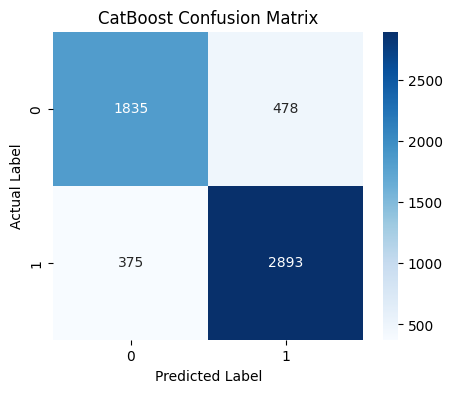

In [19]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("CatBoost Confusion Matrix")
plt.show()

#RandomForestClassifier

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, classification_report, confusion_matrix

# Detect categorical columns
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
print("Categorical cols used:", cat_cols)

# Preprocessing (One-Hot Encoding for categorical features)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# Pipeline
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf_model)
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_proba = model.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

# Metrics
print("Validation metrics:")
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
Validation metrics:
ROC AUC: 0.9130814151930363
Accuracy: 0.8369467837305142
F1: 0.8638132295719845

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.77      0.80      2313
           1       0.85      0.88      0.86      3268

    accuracy                           0.84      5581
   macro avg       0.83      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581


Confusion matrix:
 [[1785  528]
 [ 382 2886]]


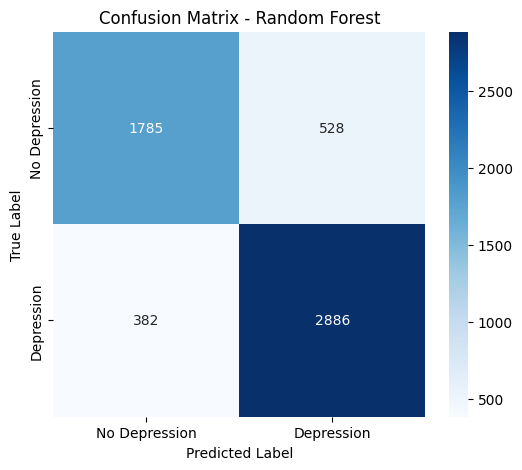

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Depression','Depression'],
    yticklabels=['No Depression','Depression']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

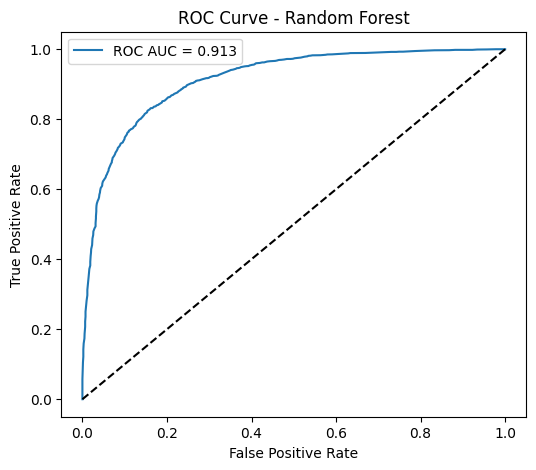

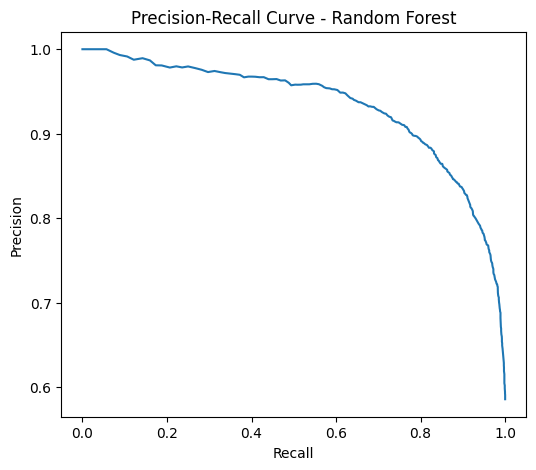

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

# Detect categorical columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Encoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

# Pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', rf_model)
])

# Train model
model.fit(X_train, y_train)

# Probability prediction
y_proba = model.predict_proba(X_test)[:,1]

# ================= ROC Curve =================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()

# ================= Precision Recall Curve =================
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Random Forest')
plt.show()

#Support Vector Machine Classifier

In [23]:
from sklearn.svm import SVC
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Detect categorical columns
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
print("Categorical cols used:", cat_cols)

# Preprocessing (Encode categorical columns)
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Support Vector Machine Model
svm_model = SVC(
    kernel='rbf',
    probability=True,
    random_state=42
)

# Pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', svm_model)
])

# Train Model
model.fit(X_train, y_train)

# Predictions
y_proba = model.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)

# Evaluation
print("Validation metrics:")
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
Validation metrics:
ROC AUC: 0.9175964335475979
Accuracy: 0.846084931015947
F1: 0.8708464892497368

Classification report:
               precision    recall  f1-score   support

           0       0.83      0.79      0.81      2313
           1       0.86      0.89      0.87      3268

    accuracy                           0.85      5581
   macro avg       0.84      0.84      0.84      5581
weighted avg       0.85      0.85      0.85      5581


Confusion matrix:
 [[1826  487]
 [ 372 2896]]


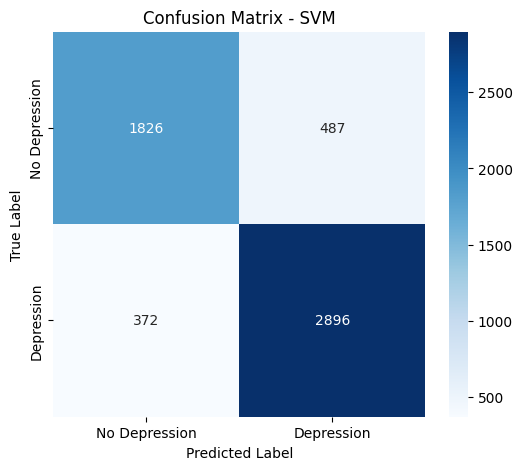

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Depression','Depression'],
    yticklabels=['No Depression','Depression']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - SVM")
plt.show()

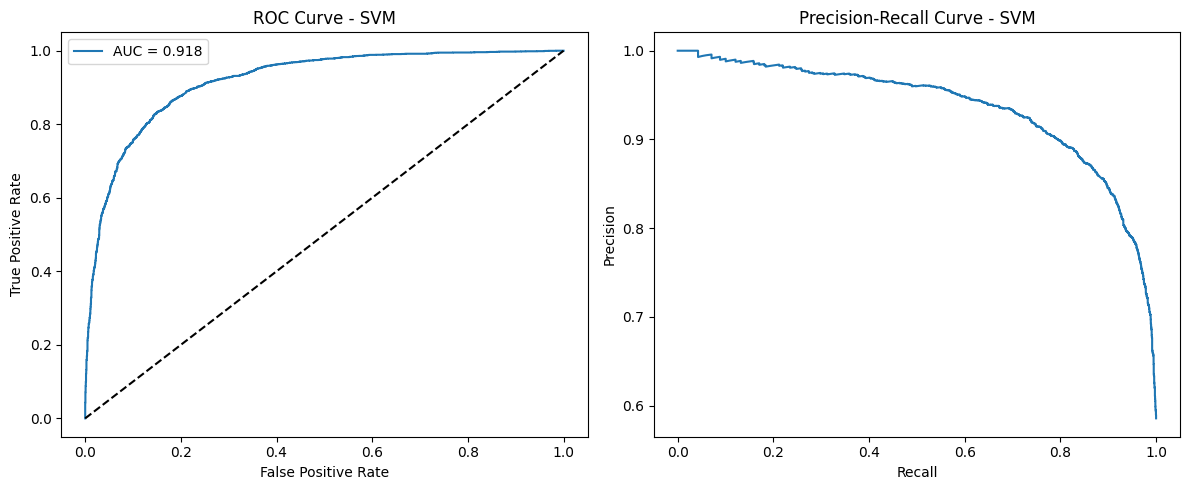

In [25]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# ================= ROC Curve =================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# ================= PR Curve =================
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Plot both curves
plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

# Precision Recall Curve
plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM")

plt.tight_layout()
plt.show()

#Logistic Regression classifier

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Detect categorical columns
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
print("Categorical cols used:", cat_cols)

# Encode categorical variables
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Logistic Regression Model
log_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', log_model)
])

# Train model
model.fit(X_train, y_train)

# Predictions
y_proba = model.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)

# Evaluation
print("Validation metrics:")
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
Validation metrics:
ROC AUC: 0.9172690042604171
Accuracy: 0.8407095502598101
F1: 0.8660135644310475

Classification report:
               precision    recall  f1-score   support

           0       0.82      0.79      0.80      2313
           1       0.85      0.88      0.87      3268

    accuracy                           0.84      5581
   macro avg       0.84      0.83      0.83      5581
weighted avg       0.84      0.84      0.84      5581


Confusion matrix:
 [[1819  494]
 [ 395 2873]]


Confusion Matrix:
 [[1819  494]
 [ 395 2873]]


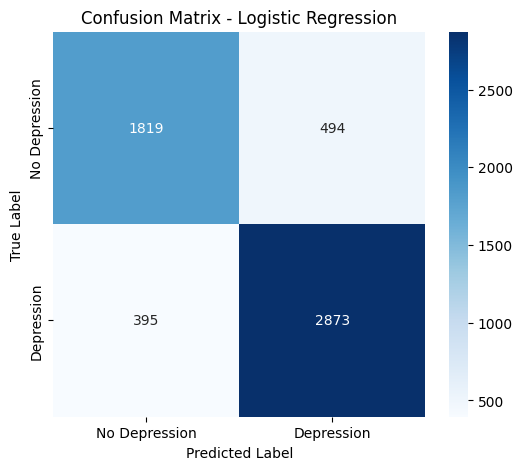

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Depression','Depression'],
    yticklabels=['No Depression','Depression']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

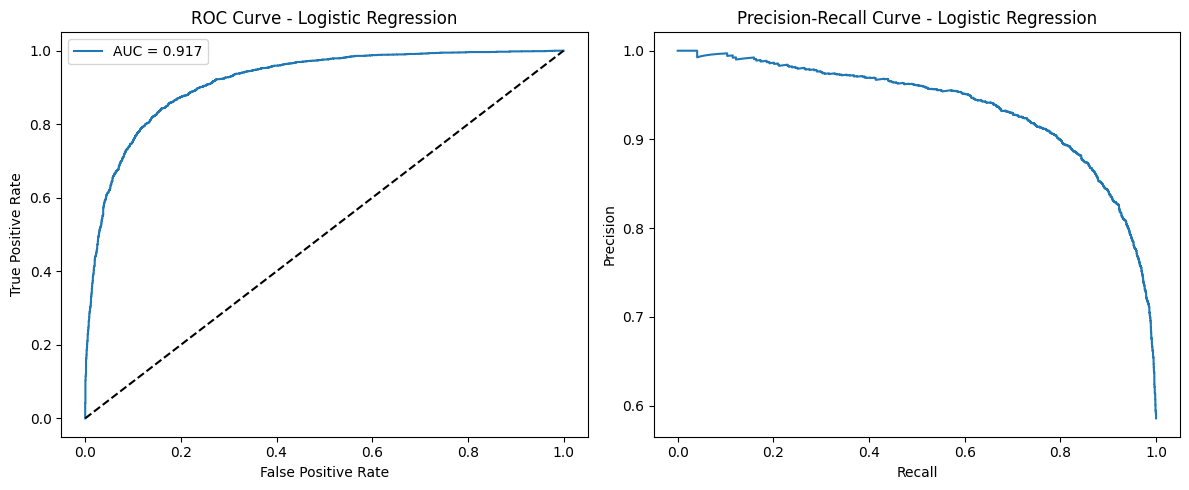

In [28]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Precision Recall values
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Plot both curves
plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

# Precision-Recall Curve
plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")

plt.tight_layout()
plt.show()

#DecisionTreeClassifier

In [29]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report, confusion_matrix

# Detect categorical columns
cat_cols = list(X_train.select_dtypes(include=['object', 'category']).columns)
print("Categorical cols used:", cat_cols)

# Encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

# Decision Tree Model
dt_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

# Pipeline
model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('classifier', dt_model)
])

# Train Model
model.fit(X_train, y_train)

# Predictions
y_proba = model.predict_proba(X_test)[:,1]
y_pred  = (y_proba >= 0.5).astype(int)

# Evaluation
print("Validation metrics:")
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))

print("\nClassification report:\n", classification_report(y_test, y_pred))
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

Categorical cols used: ['Gender', 'City', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Financial Stress', 'Family History of Mental Illness']
Validation metrics:
ROC AUC: 0.8912014657190137
Accuracy: 0.8190288478767246
F1: 0.8468768950879321

Classification report:
               precision    recall  f1-score   support

           0       0.79      0.77      0.78      2313
           1       0.84      0.85      0.85      3268

    accuracy                           0.82      5581
   macro avg       0.81      0.81      0.81      5581
weighted avg       0.82      0.82      0.82      5581


Confusion matrix:
 [[1778  535]
 [ 475 2793]]


Confusion Matrix:
 [[1778  535]
 [ 475 2793]]


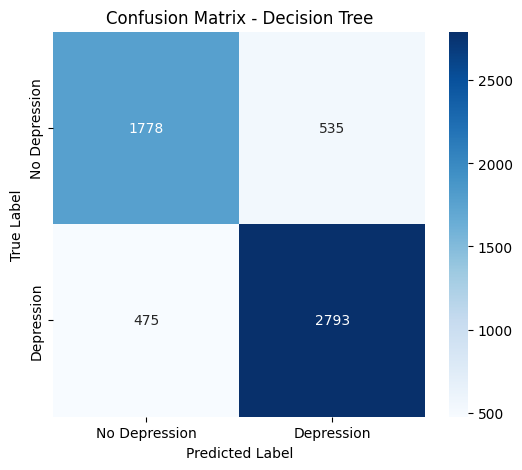

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Create Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:\n", cm)

# Plot Heatmap
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['No Depression','Depression'],
    yticklabels=['No Depression','Depression']
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Decision Tree")
plt.show()

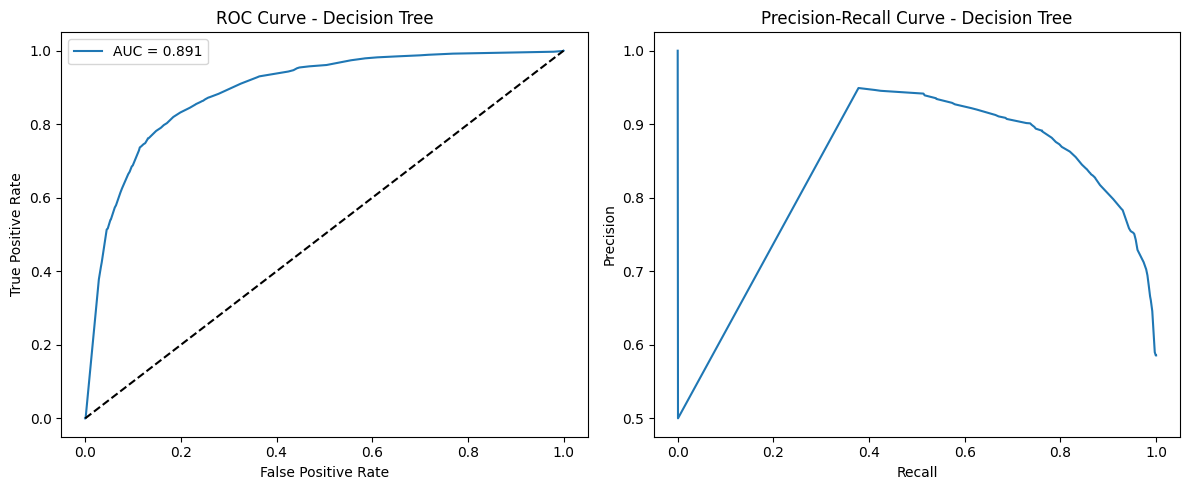

In [31]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve
import matplotlib.pyplot as plt

# ROC values
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

# Precision-Recall values
precision, recall, _ = precision_recall_curve(y_test, y_proba)

# Plot both curves
plt.figure(figsize=(12,5))

# ROC Curve
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

# Precision-Recall Curve
plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Decision Tree")

plt.tight_layout()
plt.show()